In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dump_io as io

from astropy import constants as const, units as u
import pickle as pk

In [54]:
dirc = 'rho1e-12/kappa0.0/out/'
dirc = 'rho1e-12/template/out/'
dirc = 'rho1e-13/kappa-2.5/out/'

exp = -int(np.log10(float(dirc.split('/')[0][3:]))) # lazy


def load(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer][0]

In [66]:
dmp = io.readDump(f'{dirc}/dump.0000.dmp')
x, y, z = dmp.x1, dmp.x2, dmp.x3
dz = dmp.x3r - dmp.x3l

print(dmp.data.keys())
mu = 2.353

NX1, NX2, NX3 = x.size, y.size, z.size

rho0 = 1
prs0 = 1
tmp0 = mu * prs0 / rho0
#Er0  = aR * tmp0**4

dict_keys(['ERAD', 'Vc-PRS', 'Vc-RHO', 'Vc-VX1', 'Vc-VX2', 'analysisLast', 'dt', 'dumpFileNumber', 'dumpLast', 'geometry', 'periodicity', 'time', 'vtkFileNumber', 'vtkLast'])


In [71]:
from scipy.optimize import curve_fit
def f(x, a, b, c, d, e): return a * np.sin(b*x+c) * np.exp(d*x) + e
def fit_eigenvalue(t, x, **kwargs):
    try: return curve_fit(f, t, x, **kwargs)[0]
    except: return np.nan * np.ones(5)

with open(f'new-rho1e-{exp}.pk', 'rb') as file: data = pk.load(file)
i = np.argmin(np.abs(data['kappa']-10**-2.5))
t, rho, vx1, prs, Er = np.genfromtxt(f'{dirc}/../data_at_x0.dat', unpack=True)

t0 = 14.56

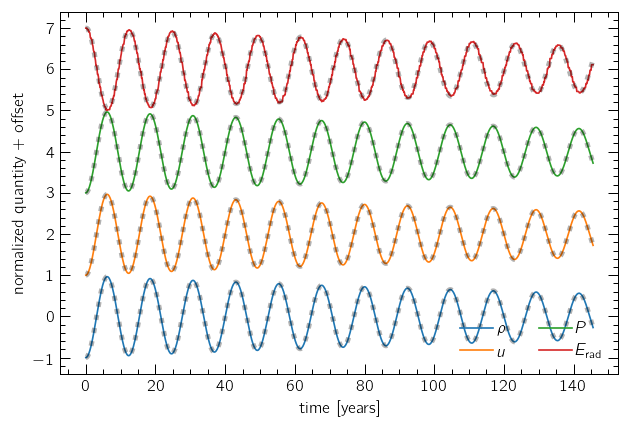

In [72]:
fig, ax = plt.subplots(dpi=120)

def process(qty, idx):
    qty = qty / qty.mean() - 1
    qty /= np.abs(qty).max()
    qty += 2*idx
    return qty

labels = [r'$\rho$', '$u$', '$P$', '$E_\mathrm{rad}$']
t0=14.56
for idx, q in enumerate([rho, vx1, prs, Er]):
    c    = f'C{idx}'
    popt = fit_eigenvalue(t, q, p0=[0, 7, np.pi/2, -0.5, 0], maxfev=15000)
    mag, imag, phase, real, off = popt

    qty = process(q, idx)
    ax.plot(t*t0, qty, c=c, label=labels[idx])
    popt[1], popt[3] = data['eigenimag_exp'][i], -data['eigenreal_exp'][i]
    qty = process(f(t, *popt), idx)
    ax.plot(t*t0, qty, alpha=0.3, lw=3, c='k', ls=':')
    
ax.legend(ncol=2)
ax.set_ylabel(r'normalized quantity $+$ offset')
ax.set_xlabel(r'time [years]')
# fig.savefig('../figures/dynamic-osc.pdf', bbox_inches='tight')
plt.show()

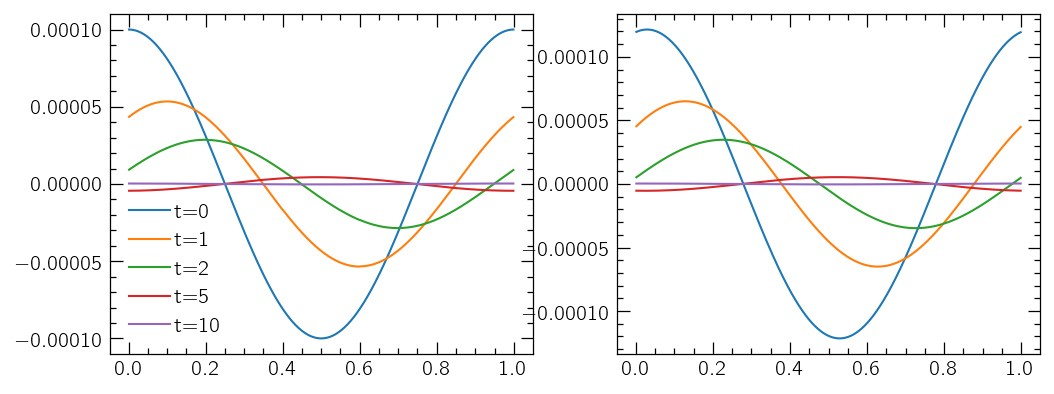

In [10]:
fig, ax = plt.subplots(ncols=2, dpi=150, figsize=(8,3))

for idx, i in enumerate([0, 1, 2, 5, 10, 100]):
    c = f'C{idx}'
    try: rho = load(i=i, var='Vc-RHO')
    except FileNotFoundError: continue
    prs = load(i=i, var='Vc-PRS')
    tmp = mu * prs / rho
    ax[0].plot(x, rho[0]-1, c=c, label=f't={i}')
    ax[1].plot(x, prs[0]-1, c=c)
    
ax[0].legend()
plt.show()